In [14]:
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
from math import radians, sin, cos, sqrt, asin
import re
import warnings
warnings.filterwarnings('ignore')


In [15]:
# ================================
# CONFIGURATION 
# ================================
OBS_BASE = Path("./OBS/data")
ERA5_BASE = Path("./ERA5/processed_version")
DANRA_BASE = Path("./DANRA/new")

WIND_VARIABLE_NAMES = [
    'wind_speed', 'wind_speed_filtered', 'ws', 'wind', 'wspd',
    'wind_speed_10m', 'wind_speed_100m', 'sfc_wind', 'wind_spd',
    'WS10M', 'WS100M', 'WSPD', 'WIND_SPEED', 'wind_speed_mean',
    'wind_speed_avg', 'nl_wspd', 'F'
]

TIME_DIMENSION_NAMES = [
    'time', 'Time', 'TIME', 't', 'T', 'datetime', 'Date', 'timestamp', 'valid_time'
]

TARGET_HEIGHT = 80.0
TARGET_YEARS = [2022] #list(range(2001, 2024)) 

# Resampling options
RESAMPLE_OBS_TO_HOURLY = True  # Set to True to resample OBS data to hourly
RESAMPLE_METHOD = 'mean'       # 'mean', 'median', or 'max'

# Correlation fit options
MIN_DISTANCE = 0.1
MAX_DISTANCE = 1500.0
EXPONENTIAL_MODEL = lambda d, L: np.exp(-d / L)

# Station metadata file
STATION_METADATA_FILE = "locations.csv"

In [16]:
# ================================
# SECTION 1: HELPER FUNCTIONS
# ================================

def format_years_string(target_years):
    """Format years string for display and filenames."""
    if len(target_years) == 1:
        return str(target_years[0])
    else:
        return f"{min(target_years)}-{max(target_years)}"

def haversine(lat1, lon1, lat2, lon2):
    """Calculate great-circle distance between two points in km."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    return R * c

def find_time_dimension(ds):
    """Return name of time coordinate/dimension."""
    for coord in TIME_DIMENSION_NAMES:
        if coord in ds.coords:
            return coord
    for dim in TIME_DIMENSION_NAMES:
        if dim in ds.dims:
            return dim
    for coord in ds.coords:
        try:
            if np.issubdtype(ds[coord].dtype, np.datetime64):
                return coord
        except:
            continue
    return None

def extract_wind_speed_from_netcdf(ds, target_height, return_actual_height=False):
    """Extract wind speed series from NetCDF file."""
    wind_var = None
    for var_name in WIND_VARIABLE_NAMES:
        if var_name in ds.data_vars:
            wind_var = var_name
            break
    
    if wind_var is None:
        raise KeyError(f"No wind speed variable found. Tried: {WIND_VARIABLE_NAMES}")
    
    wind_data = ds[wind_var]
    actual_height = target_height
    
    # Handle different dimension structures
    if 'height' in wind_data.dims:
        heights = wind_data.coords['height'].values
        height_idx = np.argmin(np.abs(heights - target_height))
        actual_height = heights[height_idx]
        wind_data = wind_data.isel(height=height_idx)
    elif 'lev_wspd' in wind_data.dims:
        levels = wind_data.coords['lev_wspd'].values
        level_idx = np.argmin(np.abs(levels - target_height))
        actual_height = levels[level_idx]
        wind_data = wind_data.isel(lev_wspd=level_idx)
    elif 'altitude' in wind_data.dims:
        levels = wind_data.coords['altitude'].values
        level_idx = np.argmin(np.abs(levels - target_height))
        actual_height = levels[level_idx]
        wind_data = wind_data.isel(altitude=level_idx)
    else:
        height_like_dims = ['level', 'lev', 'z', 'altitude', 'height_above_ground']
        for dim in height_like_dims:
            if dim in wind_data.dims:
                levels = wind_data.coords[dim].values
                level_idx = np.argmin(np.abs(levels - target_height))
                actual_height = levels[level_idx]
                wind_data = wind_data.isel({dim: level_idx})
                break
    
    series = wind_data.to_series()
    
    if isinstance(series.index, pd.MultiIndex):
        time_levels = [l for l in series.index.names if l and ('time' in l.lower() or 'valid' in l.lower())]
        if time_levels:
            series = series.droplevel([l for l in series.index.names if l not in time_levels])
    
    if not isinstance(series.index, pd.DatetimeIndex):
        try:
            series.index = pd.to_datetime(series.index)
        except:
            time_dim = find_time_dimension(ds)
            if time_dim and time_dim in ds.coords:
                series.index = pd.to_datetime(ds.coords[time_dim].values)
    
    series = series.rename('wind_speed').dropna()
    
    if return_actual_height:
        return series, actual_height
    return series

def get_netcdf_coordinates(ds):
    """Extract coordinates from NetCDF file."""
    lat, lon = None, None
    
    for name in ['latitude', 'lat', 'actual_latitude']:
        if name in ds.coords:
            lat = float(ds.coords[name].values)
            break
    for name in ['longitude', 'lon', 'actual_longitude']:
        if name in ds.coords:
            lon = float(ds.coords[name].values)
            break
    
    if lat is None and 'latitude' in ds.attrs:
        lat = float(ds.attrs['latitude'])
    if lon is None and 'longitude' in ds.attrs:
        lon = float(ds.attrs['longitude'])
    
    if lat is None and 'latitude' in ds.data_vars:
        lat = float(ds['latitude'].values)
    if lon is None and 'longitude' in ds.data_vars:
        lon = float(ds['longitude'].values)
    
    if lat is None or lon is None:
        raise KeyError(f"Could not find coordinates. Available coords: {list(ds.coords.keys())}")
    
    return lat, lon

def load_station_metadata(metadata_file):
    """Load station metadata from CSV file."""
    if not Path(metadata_file).exists():
        print(f"Warning: Station metadata file {metadata_file} not found")
        return {}
    
    df_meta = pd.read_csv(metadata_file)
    station_info = {}
    
    for _, row in df_meta.iterrows():
        station_name = row['station'].strip()
        
        lev_wspd = []
        if pd.notna(row.get('lev_wspd', '')) and str(row['lev_wspd']).strip():
            wspd_str = str(row['lev_wspd']).strip()
            if ',' in wspd_str:
                lev_wspd = [float(h.strip()) for h in wspd_str.split(',') if h.strip()]
            else:
                lev_wspd = [float(h) for h in wspd_str.split() if h.strip()]
        
        station_info[station_name] = {
            'lat': float(row['lat']),
            'lon': float(row['lon']),
            'lev_wspd': lev_wspd,
        }
    
    print(f"Loaded metadata for {len(station_info)} stations")
    return station_info

def get_csv_coordinates(filename, df=None, station_metadata=None):
    """Extract coordinates from CSV filename or metadata."""
    stem = Path(filename).stem
    
    station_name = stem
    for suffix in ['_ERA5', '_ERA5_CSV', '_obs', '_station', '_met', '_combined']:
        if station_name.endswith(suffix):
            station_name = station_name[:-len(suffix)]
            break
    
    if station_metadata and station_name in station_metadata:
        info = station_metadata[station_name]
        return info['lat'], info['lon']
    
    if station_metadata:
        for meta_station in station_metadata.keys():
            if meta_station.lower() in stem.lower() or stem.lower() in meta_station.lower():
                info = station_metadata[meta_station]
                return info['lat'], info['lon']
    
    pattern = r'([-+]?\d*\.?\d+)[_-]([-+]?\d*\.?\d+)$'
    match = re.search(pattern, stem)
    if match:
        lat = float(match.group(1))
        lon = float(match.group(2))
        return lat, lon
    
    if df is not None:
        if 'latitude' in df.columns and 'longitude' in df.columns:
            return float(df['latitude'].iloc[0]), float(df['longitude'].iloc[0])
        if 'lat' in df.columns and 'lon' in df.columns:
            return float(df['lat'].iloc[0]), float(df['lon'].iloc[0])
    
    return None, None

def extract_wind_speed_from_csv(df, target_height, station_name=None, station_metadata=None, return_actual_height=False):
    """Extract wind speed series from ERA5 CSV DataFrame."""
    available_heights = []
    
    if station_name and station_metadata and station_name in station_metadata:
        available_heights = station_metadata[station_name]['lev_wspd']
    
    if not available_heights:
        for col in df.columns:
            if col.startswith('U') and col[1:].isdigit():
                available_heights.append(int(col[1:]))
        available_heights.sort()
    
    if not available_heights:
        raise ValueError(f"No wind speed columns found. Available: {df.columns.tolist()}")
    
    closest_height = min(available_heights, key=lambda h: abs(h - target_height))
    wind_column = f'U{closest_height}'
    
    if wind_column not in df.columns:
        alt_columns = [f'ws_{closest_height}', f'wind_speed_{closest_height}', f'wspd_{closest_height}']
        for alt in alt_columns:
            if alt in df.columns:
                wind_column = alt
                break
        else:
            raise ValueError(f"Could not find wind speed column for height {closest_height}m")
    
    series = df[wind_column].copy().rename('wind_speed').dropna()
    
    if return_actual_height:
        return series, closest_height
    return series


## SECTION 2: DATA LOADING & SORTING


In [17]:
print("\n" + "=" * 70)
print("SECTION 1: DATA LOADING & SORTING")
print("=" * 70)

# Find files
obs_files = sorted(OBS_BASE.glob("*.nc"))
era5_files = sorted(ERA5_BASE.glob("*.csv"))
danra_files = sorted(DANRA_BASE.glob("*.nc"))

print(f"\nFound {len(obs_files)} OBS NetCDF files")
print(f"Found {len(era5_files)} ERA5 CSV files")
print(f"Found {len(danra_files)} DANRA NetCDF files")

# Load station metadata
station_metadata = load_station_metadata(STATION_METADATA_FILE)



SECTION 1: DATA LOADING & SORTING

Found 15 OBS NetCDF files
Found 15 ERA5 CSV files
Found 15 DANRA NetCDF files
Loaded metadata for 15 stations


In [18]:
# ================================
# LOAD OBSERVATIONS
# ================================
print("\n" + "-" * 50)
print("LOADING OBSERVATIONS")
print("-" * 50)

def normalize_station_name(name):
    """Normalize station name for matching"""
    name_lower = name.lower().strip()  # Remove leading/trailing spaces
    
    # Define mapping of station names
    name_mapping = {
        'fino1': 'FINO1',
        'fino2': 'FINO2', 
        'fino3': 'FINO3',
        'cabauw': 'Cabauw',
        'hovsore': 'Hovsore', 
        'oesterild': 'Oesterild',
        'hamburg': 'Hamburg',
        'balticsea_lot3': 'Balticsea_lot3',
        'balticsea_lot4': 'Balticsea_lot4',
        'northsea_lot1': 'Northsea_lot1',
        'northsea_lot2': 'Northsea_lot2',
        'n-03-07-uw_v2': 'Windcube_N-03-07-UW_V2',
        'n-03-07-uw': 'Windcube_N-03-07-UW_V2',  # Handle without _v2
        'wea_xr_1500m_vad': 'WEA_XR_1500m_VAD',
        'wea_xr_1500m': 'WEA_XR_1500m_VAD',  # Handle without _vad
        'uw_xr_1600m_vad': 'UW_XR_1600m_VAD',
        'uw_xr_1600m': 'UW_XR_1600m_VAD',  # Handle without _vad
        'uw_xr_3000m_vad': 'UW_XR_3000m_VAD',
        'uw_xr_3000m': 'UW_XR_3000m_VAD'  # Handle without _vad
    }
    
    # Try to find and return the standardized station name
    for station in name_mapping.keys():
        if station in name_lower:
            return name_mapping[station]
    
    # If no station found, clean up common patterns
    # Remove common suffixes and year patterns
    name_lower = re.sub(r'_[^_]*$', '', name_lower)  # Remove last underscore segment
    name_lower = re.sub(r'[-_]?\d{4}([-_]?\d{4})?$', '', name_lower)  # Remove year patterns
    name_lower = re.sub(r'\.(nc|csv)$', '', name_lower)  # Remove file extensions
    name_lower = re.sub(r'\s+$', '', name_lower)  # Remove trailing spaces
    
    # Special handling for remaining names
    if name_lower in ['fino1', 'fino2', 'fino3']:
        return name_lower.upper()
    
    return name_lower.title()  # Capitalize first letter of each word

def get_station_stem(filepath):
    """Extract base station name from filename"""
    return normalize_station_name(Path(filepath).stem)

def get_csv_coordinates(filename, df=None, station_metadata=None):
    """Extract coordinates from CSV filename or metadata."""
    stem = Path(filename).stem
    
    # Clean the station name
    station_name = normalize_station_name(stem)
    
    # Try metadata first
    if station_metadata and station_name in station_metadata:
        info = station_metadata[station_name]
        return info['lat'], info['lon']
    
    # Try partial matching with metadata
    if station_metadata:
        for meta_station, info in station_metadata.items():
            if meta_station.lower() in station_name.lower() or station_name.lower() in meta_station.lower():
                return info['lat'], info['lon']
    
    # Try to extract from filename
    pattern = r'([-+]?\d*\.?\d+)[_-]([-+]?\d*\.?\d+)$'
    match = re.search(pattern, stem)
    if match:
        lat = float(match.group(1))
        lon = float(match.group(2))
        return lat, lon
    
    # Try from dataframe
    if df is not None:
        if 'latitude' in df.columns and 'longitude' in df.columns:
            return float(df['latitude'].iloc[0]), float(df['longitude'].iloc[0])
        if 'lat' in df.columns and 'lon' in df.columns:
            return float(df['lat'].iloc[0]), float(df['lon'].iloc[0])
    
    # Try to get from metadata by pattern matching without station_metadata
    if station_metadata:
        for meta_station, info in station_metadata.items():
            # Check if any part of the filename matches any part of the metadata station name
            stem_parts = station_name.lower().split('_')
            meta_parts = meta_station.lower().split('_')
            if any(part in ' '.join(meta_parts) for part in stem_parts if len(part) > 3):
                return info['lat'], info['lon']
    
    return None, None

def extract_wind_speed_from_csv(df, target_height, station_name=None, station_metadata=None, return_actual_height=False):
    """Extract wind speed series from ERA5 CSV DataFrame."""
    available_heights = []
    
    # First try to get heights from metadata
    if station_name and station_metadata and station_name in station_metadata:
        available_heights = station_metadata[station_name]['lev_wspd']
    
    # If not in metadata, extract from column names
    if not available_heights:
        for col in df.columns:
            # Look for U followed by number (height)
            if col.startswith('U') and col[1:].replace('.', '').isdigit():
                try:
                    height = float(col[1:])
                    available_heights.append(height)
                except:
                    pass
        
        # Also try other column patterns
        if not available_heights:
            for col in df.columns:
                if 'wind_speed' in col.lower() or 'wspd' in col.lower() or 'ws_' in col.lower():
                    match = re.search(r'(\d+\.?\d*)', col)
                    if match:
                        try:
                            available_heights.append(float(match.group(1)))
                        except:
                            pass
        
        available_heights = sorted(set(available_heights))  # Remove duplicates
    
    if not available_heights:
        raise ValueError(f"No wind speed columns found. Available: {df.columns.tolist()}")
    
    # Find closest height to target
    closest_height = min(available_heights, key=lambda h: abs(h - target_height))
    print(f"  Target height: {target_height}m, using closest available: {closest_height}m")
    
    # Try different column naming patterns
    wind_column = None
    
    # For U{height} format
    for suffix in ['', '.0']:
        col_name = f'U{closest_height}{suffix}'
        if col_name in df.columns:
            wind_column = col_name
            break
    
    # If not found, try with integer version
    if wind_column is None and closest_height == int(closest_height):
        col_name = f'U{int(closest_height)}'
        if col_name in df.columns:
            wind_column = col_name
    
    # If still not found, try case-insensitive search
    if wind_column is None:
        height_str = str(int(closest_height)) if closest_height == int(closest_height) else str(closest_height)
        for col in df.columns:
            col_lower = col.lower()
            if height_str in col_lower and ('wind' in col_lower or 'ws' in col_lower or 'wspd' in col_lower or col_lower.startswith('u')):
                wind_column = col
                break
    
    if wind_column is None:
        # If all else fails, try to find any U column
        for col in df.columns:
            if col.startswith('U') and col[1:].replace('.', '').isdigit():
                wind_column = col
                break
    
    if wind_column is None:
        raise ValueError(f"Could not find wind speed column for height {closest_height}m. Available columns: {df.columns.tolist()}")
    
    series = df[wind_column].copy().rename('wind_speed').dropna()
    
    if return_actual_height:
        return series, closest_height
    return series

def extract_wind_speed_from_netcdf(ds, target_height, return_actual_height=False):
    """Extract wind speed series from NetCDF file."""
    wind_var = None
    for var_name in WIND_VARIABLE_NAMES:
        if var_name in ds.data_vars:
            wind_var = var_name
            break
    
    if wind_var is None:
        raise KeyError(f"No wind speed variable found. Tried: {WIND_VARIABLE_NAMES}")
    
    wind_data = ds[wind_var]
    actual_height = target_height
    
    # Handle different dimension structures
    if 'height' in wind_data.dims:
        heights = wind_data.coords['height'].values
        height_idx = np.argmin(np.abs(heights - target_height))
        actual_height = heights[height_idx]
        wind_data = wind_data.isel(height=height_idx)
    elif 'lev_wspd' in wind_data.dims:
        levels = wind_data.coords['lev_wspd'].values
        level_idx = np.argmin(np.abs(levels - target_height))
        actual_height = levels[level_idx]
        wind_data = wind_data.isel(lev_wspd=level_idx)
    elif 'altitude' in wind_data.dims:
        levels = wind_data.coords['altitude'].values
        level_idx = np.argmin(np.abs(levels - target_height))
        actual_height = levels[level_idx]
        wind_data = wind_data.isel(altitude=level_idx)
    else:
        height_like_dims = ['level', 'lev', 'z', 'altitude', 'height_above_ground']
        for dim in height_like_dims:
            if dim in wind_data.dims:
                levels = wind_data.coords[dim].values
                level_idx = np.argmin(np.abs(levels - target_height))
                actual_height = levels[level_idx]
                wind_data = wind_data.isel({dim: level_idx})
                break
    
    # Extract series and ensure proper time index
    series = wind_data.to_series()
    
    # Handle MultiIndex
    if isinstance(series.index, pd.MultiIndex):
        time_levels = [l for l in series.index.names if l and ('time' in l.lower() or 'valid' in l.lower())]
        if time_levels:
            series = series.droplevel([l for l in series.index.names if l not in time_levels])
    
    # Ensure DatetimeIndex
    if not isinstance(series.index, pd.DatetimeIndex):
        try:
            series.index = pd.to_datetime(series.index)
        except:
            time_dim = find_time_dimension(ds)
            if time_dim and time_dim in ds.coords:
                time_values = ds.coords[time_dim].values
                # Try to decode if it's numeric
                if np.issubdtype(time_values.dtype, np.number):
                    # Try to get units
                    if hasattr(ds.coords[time_dim], 'attrs') and 'units' in ds.coords[time_dim].attrs:
                        units = ds.coords[time_dim].attrs['units']
                        if 'hours since' in units:
                            ref_date = pd.to_datetime(units.split('hours since ')[1])
                            time_values = ref_date + pd.to_timedelta(time_values, unit='h')
                        elif 'days since' in units:
                            ref_date = pd.to_datetime(units.split('days since ')[1])
                            time_values = ref_date + pd.to_timedelta(time_values, unit='D')
                    series.index = pd.to_datetime(time_values)
                else:
                    series.index = pd.to_datetime(time_values)
    
    # Drop NA and rename
    series = series.rename('wind_speed').dropna()
    
    if return_actual_height:
        return series, actual_height
    return series

def get_netcdf_coordinates(ds):
    """Extract coordinates from NetCDF file."""
    lat, lon = None, None
    
    for name in ['latitude', 'lat', 'actual_latitude']:
        if name in ds.coords:
            lat = float(ds.coords[name].values)
            break
    for name in ['longitude', 'lon', 'actual_longitude']:
        if name in ds.coords:
            lon = float(ds.coords[name].values)
            break
    
    if lat is None and 'latitude' in ds.attrs:
        lat = float(ds.attrs['latitude'])
    if lon is None and 'longitude' in ds.attrs:
        lon = float(ds.attrs['longitude'])
    
    if lat is None and 'latitude' in ds.data_vars:
        lat = float(ds['latitude'].values)
    if lon is None and 'longitude' in ds.data_vars:
        lon = float(ds['longitude'].values)
    
    if lat is None or lon is None:
        raise KeyError(f"Could not find coordinates. Available coords: {list(ds.coords.keys())}")
    
    return lat, lon

def load_station_metadata(metadata_file):
    """Load station metadata from CSV file."""
    if not Path(metadata_file).exists():
        print(f"Warning: Station metadata file {metadata_file} not found")
        return {}
    
    df_meta = pd.read_csv(metadata_file)
    station_info = {}
    
    for _, row in df_meta.iterrows():
        station_name = row['station'].strip()
        
        lev_wspd = []
        if pd.notna(row.get('lev_wspd', '')) and str(row['lev_wspd']).strip():
            wspd_str = str(row['lev_wspd']).strip()
            if ',' in wspd_str:
                lev_wspd = [float(h.strip()) for h in wspd_str.split(',') if h.strip()]
            else:
                lev_wspd = [float(h) for h in wspd_str.split() if h.strip()]
        
        station_info[station_name] = {
            'lat': float(row['lat']),
            'lon': float(row['lon']),
            'lev_wspd': lev_wspd,
        }
    
    print(f"Loaded metadata for {len(station_info)} stations")
    return station_info

# Find files
obs_files = sorted(OBS_BASE.glob("*.nc"))
era5_files = sorted(ERA5_BASE.glob("*.csv"))
danra_files = sorted(DANRA_BASE.glob("*.nc"))

print(f"\nFound {len(obs_files)} OBS NetCDF files")
print(f"Found {len(era5_files)} ERA5 CSV files")
print(f"Found {len(danra_files)} DANRA NetCDF files")

# Load station metadata
station_metadata = load_station_metadata(STATION_METADATA_FILE)

# ================================
# LOAD OBSERVATIONS
# ================================
print("\n" + "-" * 50)
print("LOADING OBSERVATIONS")
print("-" * 50)

obs_stations = {}
for f in obs_files:
    try:
        ds = xr.open_dataset(f, decode_times=True)
        
        # Get the stem (base name) of the file
        file_stem = get_station_stem(f)
        print(f"Loading OBS: {f.stem} -> normalized: {file_stem}")
        
        series, actual_h = extract_wind_speed_from_netcdf(ds, TARGET_HEIGHT, return_actual_height=True)
        lat, lon = get_netcdf_coordinates(ds)
        
        # DEBUG: Check the time index and frequency before filtering
        print(f"  Before filtering: {len(series)} data points")
        print(f"  Date range: {series.index.min()} to {series.index.max()}")
        print(f"  Available years: {sorted(set(series.index.year))}")
        
        # ALWAYS resample to hourly using mean
        if len(series) > 0:
            # Calculate original time step for debugging
            time_diffs = series.index.to_series().diff().dt.total_seconds().median()
            if not np.isnan(time_diffs):
                print(f"  Original median time step: {time_diffs/60:.1f} minutes")
            
            # Resample to hourly using mean
            print(f"  Resampling to hourly using mean")
            series = series.resample('1h').mean()
            print(f"  After resampling: {len(series)} hourly data points")
        
        # Filter by multiple years
        series = series[series.index.year.isin(TARGET_YEARS)]
        
        print(f"  After filtering to {TARGET_YEARS}: {len(series)} data points")
        if len(series) > 0:
            print(f"  Date range: {series.index.min()} to {series.index.max()}")
        
        if len(series) > 0:
            # Use the normalized stem as the key for consistency
            station_key = file_stem
            obs_stations[station_key] = {
                'series': series,
                'lat': lat,
                'lon': lon,
                'actual_height': actual_h,
                'type': 'obs',
                'stem': file_stem,
                'original_filename': f.stem
            }
            print(f"  -> {len(series)} hours at {actual_h:.1f}m (stem: {file_stem})")
        else:
            print(f"  -> No data for selected years")
            # Show available years if filtering removed all data
            if 'series' in locals() and len(series) > 0:
                all_years = sorted(set(series.index.year))
                print(f"     Available years in dataset: {all_years}")
        
        ds.close()
        
    except Exception as e:
        print(f"  Error loading {f}: {e}")
        import traceback
        traceback.print_exc()


# ================================
# LOAD ERA5
# ================================
print("\n" + "-" * 50)
print("LOADING ERA5")
print("-" * 50)

era5_stations = {}
for f in era5_files:
    try:
        df = pd.read_csv(f, parse_dates=['time'])
        df.set_index('time', inplace=True)
        
        # Get normalized stem
        file_stem = get_station_stem(f)
        print(f"Loading ERA5: {f.stem} -> normalized: {file_stem}")
        
        series, actual_h = extract_wind_speed_from_csv(df, TARGET_HEIGHT, file_stem, station_metadata, return_actual_height=True)
        lat, lon = get_csv_coordinates(f, df, station_metadata)
        
        if lat is None or lon is None:
            print(f"  -> Skipping: Could not determine coordinates")
            continue
        
        # Filter by multiple years
        series = series[series.index.year.isin(TARGET_YEARS)]
        
        if len(series) > 0:
            # Use the normalized stem as the key
            era5_stations[file_stem] = {
                'series': series,
                'lat': lat,
                'lon': lon,
                'actual_height': actual_h,
                'type': 'era5',
                'stem': file_stem,
                'original_filename': f.stem
            }
            print(f"  -> {len(series)} hours at {actual_h:.1f}m (stem: {file_stem})")
        else:
            print(f"  -> No data for selected years")
        
    except Exception as e:
        print(f"  Error loading {f}: {e}")


# ================================
# LOAD DANRA
# ================================
print("\n" + "-" * 50)
print("LOADING DANRA")
print("-" * 50)

danra_stations = {}
for f in danra_files:
    try:
        # Get normalized stem
        file_stem = get_station_stem(f)
        print(f"Loading DANRA: {f.stem} -> normalized: {file_stem}")
        
        # Open without automatic time decoding
        ds = xr.open_dataset(f, decode_times=False)
        
        # Decode analysis_time using the units attribute
        if 'analysis_time' in ds.variables:
            units_attr = ds.analysis_time.attrs.get('units', '')
            
            # Parse the reference date from units string
            match = re.search(r'hours since (.+)', units_attr)
            if match:
                ref_date_str = match.group(1).split('+')[0].split('-00:00')[0]
                ref_date = pd.to_datetime(ref_date_str)
            else:
                ref_date = pd.to_datetime('1990-09-01')
            
            # Convert analysis_time from hours since reference date to datetime
            analysis_time_hours = ds.analysis_time.values
            analysis_time = ref_date + pd.to_timedelta(analysis_time_hours, unit='h')
            
            # Handle forecast_duration
            if 'forecast_duration' in ds.variables:
                forecast_hours = ds.forecast_duration.values
                if hasattr(ds.forecast_duration, 'attrs'):
                    forecast_units = ds.forecast_duration.attrs.get('units', 'hours')
                else:
                    forecast_units = 'hours'
                
                if 'hour' in forecast_units.lower():
                    forecast_timedelta = pd.to_timedelta(forecast_hours, unit='h')
                else:
                    forecast_timedelta = pd.to_timedelta(forecast_hours)
                
                valid_time = analysis_time + forecast_timedelta
            else:
                valid_time = analysis_time
            
            ds = ds.assign_coords(valid_time=('valid_time', valid_time))
        else:
            print(f"  -> Missing analysis_time variable")
            ds.close()
            continue
        
        # Calculate wind speed from u and v components
        if 'u' in ds.variables and 'v' in ds.variables:
            ds['wind_speed'] = np.sqrt(ds['u']**2 + ds['v']**2)
        else:
            print(f"  -> No u/v components found")
            ds.close()
            continue
        
        # Get coordinates
        lat = float(ds.lat.values) if 'lat' in ds.coords else None
        lon = float(ds.lon.values) if 'lon' in ds.coords else None
        
        if lat is None or lon is None:
            lat = ds.attrs.get('lat', ds.attrs.get('latitude', None))
            lon = ds.attrs.get('lon', ds.attrs.get('longitude', None))
        
        if lat is None or lon is None:
            print(f"  -> Cannot find coordinates")
            ds.close()
            continue
        
        # Get altitudes
        if 'altitude' in ds.coords:
            altitudes = ds.altitude.values
            altitude_idx = np.argmin(np.abs(altitudes - TARGET_HEIGHT))
            actual_altitude = altitudes[altitude_idx]
        else:
            print(f"  -> No altitude coordinate")
            ds.close()
            continue
        
        # Extract wind speed at chosen altitude
        wind_speed = ds['wind_speed'].isel(altitude=altitude_idx)
        
        # Create pandas Series with proper time index
        if 'valid_time' in wind_speed.coords:
            time_index = pd.DatetimeIndex(wind_speed.valid_time.values)
        elif 'time' in wind_speed.coords:
            time_index = pd.DatetimeIndex(wind_speed.time.values)
        else:
            print(f"  -> No time coordinate found")
            ds.close()
            continue
        
        series = pd.Series(wind_speed.values, index=time_index)
        series = series.dropna()
        series = series[series.index.year.isin(TARGET_YEARS)]
        
        if len(series) > 0:
            # Use the normalized stem as the key
            danra_stations[file_stem] = {
                'series': series, 
                'lat': float(lat), 
                'lon': float(lon),
                'actual_height': actual_altitude,
                'type': 'danra',
                'stem': file_stem,
                'original_filename': f.stem
            }
            print(f"  -> {len(series)} hours at {actual_altitude:.1f}m (stem: {file_stem})")
        else:
            print(f"  -> No data for selected years")
            # Debug: show available years
            all_series = pd.Series(wind_speed.values, index=time_index)
            all_series = all_series.dropna()
            if len(all_series) > 0:
                available_years = sorted(set(all_series.index.year))
                print(f"     Available years: {available_years}")
        
        ds.close()
        
    except Exception as e:
        print(f"  Error loading {f}: {e}")
        import traceback
        traceback.print_exc()


# ================================
# FIND MATCHING STATIONS
# ================================
print("\n" + "=" * 70)
print("FINDING MATCHING STATIONS")
print("=" * 70)

# Since we now use normalized stems as keys, all stations with the same stem 
# will naturally match across datasets
common_stems = set(obs_stations.keys()) & set(era5_stations.keys()) & set(danra_stations.keys())
print(f"\nFound {len(common_stems)} common stations: {sorted(common_stems)}")

# Show detailed information for common stations
print("\nCommon station details:")
for stem in sorted(common_stems):
    print(f"\n  {stem}:")
    print(f"    OBS:   {obs_stations[stem]['original_filename']} ({len(obs_stations[stem]['series'])} hours)")
    print(f"    ERA5:  {era5_stations[stem]['original_filename']} ({len(era5_stations[stem]['series'])} hours)")
    print(f"    DANRA: {danra_stations[stem]['original_filename']} ({len(danra_stations[stem]['series'])} hours)")

# Show stations that don't have matches
obs_only = set(obs_stations.keys()) - common_stems
era5_only = set(era5_stations.keys()) - common_stems
danra_only = set(danra_stations.keys()) - common_stems

print("\n" + "-" * 50)
print("STATIONS WITHOUT MATCHES")
print("-" * 50)

if obs_only:
    print(f"\nOBS only: {sorted(obs_only)}")
if era5_only:
    print(f"ERA5 only: {sorted(era5_only)}")
if danra_only:
    print(f"DANRA only: {sorted(danra_only)}")

# Filter to only common stations for analysis
filtered_obs = {stem: obs_stations[stem] for stem in common_stems}
filtered_era5 = {stem: era5_stations[stem] for stem in common_stems}
filtered_danra = {stem: danra_stations[stem] for stem in common_stems}

print(f"\nFiltered station counts:")
print(f"  OBS:   {len(filtered_obs)}")
print(f"  ERA5:  {len(filtered_era5)}")
print(f"  DANRA: {len(filtered_danra)}")

# ================================
# DATA LOADING SUMMARY
# ================================
print("\n" + "=" * 50)
print("DATA LOADING SUMMARY")
print("=" * 50)
print(f"OBS stations loaded:  {len(obs_stations)}")
print(f"ERA5 stations loaded: {len(era5_stations)}")
print(f"DANRA stations loaded: {len(danra_stations)}")
print(f"\nCommon stations (all three): {len(common_stems)}")
if common_stems:
    print(f"  {sorted(common_stems)}")


--------------------------------------------------
LOADING OBSERVATIONS
--------------------------------------------------

Found 15 OBS NetCDF files
Found 15 ERA5 CSV files
Found 15 DANRA NetCDF files
Loaded metadata for 15 stations

--------------------------------------------------
LOADING OBSERVATIONS
--------------------------------------------------
Loading OBS: balticsea_lot3 -> normalized: Balticsea_lot3
  Before filtering: 16895 data points
  Date range: 2021-11-21 16:00:00 to 2022-11-21 15:30:00
  Available years: [2021, 2022]
  Original median time step: 30.0 minutes
  Resampling to hourly using mean
  After resampling: 8760 hourly data points
  After filtering to [2022]: 7792 data points
  Date range: 2022-01-01 00:00:00 to 2022-11-21 15:00:00
  -> 7792 hours at 90.0m (stem: Balticsea_lot3)
Loading OBS: balticsea_lot4 -> normalized: Balticsea_lot4
  Before filtering: 31937 data points
  Date range: 2021-11-22 16:00:00 to 2023-11-22 16:00:00
  Available years: [2021, 2022, 

In [19]:
# ================================
# DATA LOADING SUMMARY
# ================================
print("\n" + "=" * 50)
print("DATA LOADING SUMMARY")
print("=" * 50)
print(f"OBS stations loaded:  {len(obs_stations)}")
print(f"ERA5 stations loaded: {len(era5_stations)}")
print(f"DANRA stations loaded: {len(danra_stations)}")

# Find common stations
obs_names = set(obs_stations.keys())
era5_names = set(era5_stations.keys())
danra_names = set(danra_stations.keys())

print(obs_names)

common_all = obs_names & era5_names & danra_names
common_obs_era5 = obs_names & era5_names
common_obs_danra = obs_names & danra_names

print(f"\nCommon stations (all three): {len(stem)}")
if stem:
    print(f"  {sorted(common_all)}")
print(f"Common stations (OBS+ERA5): {len(common_obs_era5)}")
print(f"Common stations (OBS+DANRA): {len(common_obs_danra)}")

# Store data in a dictionary for the analysis section
loaded_data = {
    'obs': obs_stations,
    'era5': era5_stations,
    'danra': danra_stations,
    'common_all': common_all,
    'common_obs_era5': common_obs_era5,
    'common_obs_danra': common_obs_danra
}



DATA LOADING SUMMARY
OBS stations loaded:  11
ERA5 stations loaded: 14
DANRA stations loaded: 11
{'Cabauw', 'Balticsea_lot4', 'FINO1', 'Oesterild', 'FINO2', 'Northsea_lot1', 'Balticsea_lot3', 'Northsea_lot2', 'Hamburg', 'Hovsore', 'FINO3'}

Common stations (all three): 9
  ['Balticsea_lot3', 'Balticsea_lot4', 'Cabauw', 'FINO1', 'FINO2', 'FINO3', 'Hamburg', 'Hovsore', 'Northsea_lot1', 'Northsea_lot2', 'Oesterild']
Common stations (OBS+ERA5): 11
Common stations (OBS+DANRA): 11


# SECTION 3: CORRELATION ANALYSIS FUNCTIONS

In [20]:
def compute_correlations_and_distances(stations, dataset_name, target_years):
    """Compute pairwise correlations and distances for a set of stations."""
    if len(stations) < 2:
        print(f"  {dataset_name}: Need at least 2 stations, got {len(stations)}")
        return [], [], []
    
    years_str = format_years_string(target_years)
    
    # Get station names
    station_names = list(stations.keys())
    n = len(station_names)
    
    if n < 2:
        return [], [], []
    
    # Get coordinates
    coords = []
    valid_stations = []
    for name in station_names:
        if name in stations:
            coords.append((stations[name]['lat'], stations[name]['lon']))
            valid_stations.append(name)
    
    # Collect pairs
    distances = []
    correlations = []
    pair_names = []
    used_stations = set()
    
    for i in range(n):
        for j in range(i+1, n):
            name_i = valid_stations[i]
            name_j = valid_stations[j]
            
            # Get the two time series
            series_i = stations[name_i]['series']
            series_j = stations[name_j]['series']
            
            # Find common timestamps for this specific pair
            common_idx = series_i.index.intersection(series_j.index)
            
            # Only use pairs with enough overlap (at least 100 timestamps)
            if len(common_idx) < 100:
                continue
            
            # Calculate correlation on the overlapping period
            corr = series_i.reindex(common_idx).corr(series_j.reindex(common_idx))
            
            if not np.isnan(corr):
                # Calculate distance
                dist = haversine(coords[i][0], coords[i][1], coords[j][0], coords[j][1])
                
                if MIN_DISTANCE <= dist <= MAX_DISTANCE:
                    distances.append(dist)
                    correlations.append(corr)
                    pair_names.append(f"{name_i}-{name_j}")
                    used_stations.add(name_i)
                    used_stations.add(name_j)
    
    print(f"  {dataset_name}: Found {len(distances)} valid pairs for {years_str}")
    if len(distances) > 0:
        print(f"  Used stations: {sorted(used_stations)}")
    
    return distances, correlations, pair_names

def fit_exponential_model(distances, correlations, dataset_name):
    """Fit exponential model and return correlation length."""
    if len(distances) < 3:
        print(f"  {dataset_name}: Insufficient pairs for fit ({len(distances)} < 3)")
        return None, None
    
    # Clean data
    valid_mask = ~(np.isnan(distances) | np.isnan(correlations) | 
                   np.isinf(distances) | np.isinf(correlations))
    distances = np.array(distances)[valid_mask]
    correlations = np.array(correlations)[valid_mask]
    
    if len(distances) < 3:
        return None, None
    
    try:
        popt, pcov = curve_fit(EXPONENTIAL_MODEL, distances, correlations, 
                              p0=50.0, bounds=(0, np.inf))
        correlation_length = popt[0]
        
        predicted = EXPONENTIAL_MODEL(distances, correlation_length)
        ss_res = np.sum((correlations - predicted) ** 2)
        ss_tot = np.sum((correlations - np.mean(correlations)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)
        
        print(f"  {dataset_name}: L = {correlation_length:.2f} km, R² = {r_squared:.3f}")
        return correlation_length, r_squared
        
    except Exception as e:
        print(f"  {dataset_name}: Fit failed - {e}")
        return None, None
    
def create_correlation_plot(obs_distances, obs_correlations, obs_L, obs_R2,
                            era5_distances, era5_correlations, era5_L, era5_R2,
                            danra_distances, danra_correlations, danra_L, danra_R2,
                            target_height, target_years, station_names=None):
    """Create the correlation comparison plot."""
    
    plt.close('all')
    fig, ax = plt.subplots(figsize=(14, 8))
    
    obs_color = 'orange'
    era5_color = 'blue'
    danra_color = 'green'
    
    # Plot OBS 
    if len(obs_distances) > 0:
        ax.scatter(obs_distances, obs_correlations, alpha=0.6, s=60, 
                  color=obs_color, marker='o', label=f'OBS - {len(obs_distances)} pairs', zorder=2)
        if obs_L is not None:
            d_fit = np.linspace(0, max(obs_distances), 100)
            ax.plot(d_fit, EXPONENTIAL_MODEL(d_fit, obs_L), '-', 
                   color=obs_color, linewidth=2.5, 
                   label=f'OBS fit: $\\exp(-d / {obs_L:.1f})$ (R²={obs_R2:.3f})', zorder=3)
    
    # Plot ERA5 
    if len(era5_distances) > 0:
        ax.scatter(era5_distances, era5_correlations, alpha=0.6, s=60, 
                  color=era5_color, marker='s', label=f'ERA5 - {len(era5_distances)} pairs', zorder=2)
        if era5_L is not None:
            d_fit = np.linspace(0, max(era5_distances), 100)
            ax.plot(d_fit, EXPONENTIAL_MODEL(d_fit, era5_L), '--', 
                   color=era5_color, linewidth=2.5, 
                   label=f'ERA5 fit: $\\exp(-d / {era5_L:.1f})$ (R²={era5_R2:.3f})', zorder=3)
    
    # Plot DANRA 
    if len(danra_distances) > 0:
        ax.scatter(danra_distances, danra_correlations, alpha=0.6, s=60, 
                  color=danra_color, marker='^', label=f'DANRA - {len(danra_distances)} pairs', zorder=2)
        if danra_L is not None:
            d_fit = np.linspace(0, max(danra_distances), 100)
            ax.plot(d_fit, EXPONENTIAL_MODEL(d_fit, danra_L), '-.', 
                   color=danra_color, linewidth=2.5, 
                   label=f'DANRA fit: $\\exp(-d / {danra_L:.1f})$ (R²={danra_R2:.3f})', zorder=3)
    
    # Formatting
    ax.set_xlabel('Distance (km)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Correlation', fontsize=16, fontweight='bold')
    
    years_str = format_years_string(target_years)
    
    # Add station info to title if available
    station_info = ""
    if station_names and len(station_names) > 0:
        station_info = f" | Stations: {len(station_names)}"
    
    ax.set_title(f'Wind Speed Correlation vs Distance\n'
                f'Comparison: OBS vs ERA5 vs DANRA | Height: {target_height}m | Period: {years_str}{station_info}', 
                fontsize=18, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.6, zorder=1)
    ax.legend(loc='best', fontsize=14, framealpha=0.95)
    ax.tick_params(axis='both', which='major', labelsize=14)
    
    # Set axis limits
    all_distances = obs_distances + era5_distances + danra_distances
    if all_distances:
        ax.set_xlim(0, max(all_distances)+50)
    ax.set_ylim(0, 1)
      
    plt.tight_layout()
    
    # Save plot
    output_filename = f'Plots/correlation_comparison_OBS_vs_ERA5_vs_DANRA_{target_height}m_{years_str}.png'
    plt.savefig(output_filename, dpi=150, bbox_inches='tight')
    print(f"\nPlot saved as '{output_filename}'")
    plt.show()
    
    return fig

# SECTION 4: MAIN CORRELATION ANALYSIS

Closed all existing figures

--------------------------------------------------
COMPUTING CORRELATIONS (Common stations only)
--------------------------------------------------
  OBS: Found 55 valid pairs for 2022
  Used stations: ['Balticsea_lot3', 'Balticsea_lot4', 'Cabauw', 'FINO1', 'FINO2', 'FINO3', 'Hamburg', 'Hovsore', 'Northsea_lot1', 'Northsea_lot2', 'Oesterild']
  ERA5: Found 53 valid pairs for 2022
  Used stations: ['Balticsea_lot3', 'Balticsea_lot4', 'Cabauw', 'FINO1', 'FINO2', 'FINO3', 'Hamburg', 'Hovsore', 'Northsea_lot1', 'Northsea_lot2', 'Oesterild']
  DANRA: Found 55 valid pairs for 2022
  Used stations: ['Balticsea_lot3', 'Balticsea_lot4', 'Cabauw', 'FINO1', 'FINO2', 'FINO3', 'Hamburg', 'Hovsore', 'Northsea_lot1', 'Northsea_lot2', 'Oesterild']

--------------------
Stations used in correlations:
  OBS:   ['Balticsea_lot3', 'Balticsea_lot4', 'Cabauw', 'FINO1', 'FINO2', 'FINO3', 'Hamburg', 'Hovsore', 'Northsea_lot1', 'Northsea_lot2', 'Oesterild'] (11 stations)
  ERA5:  [

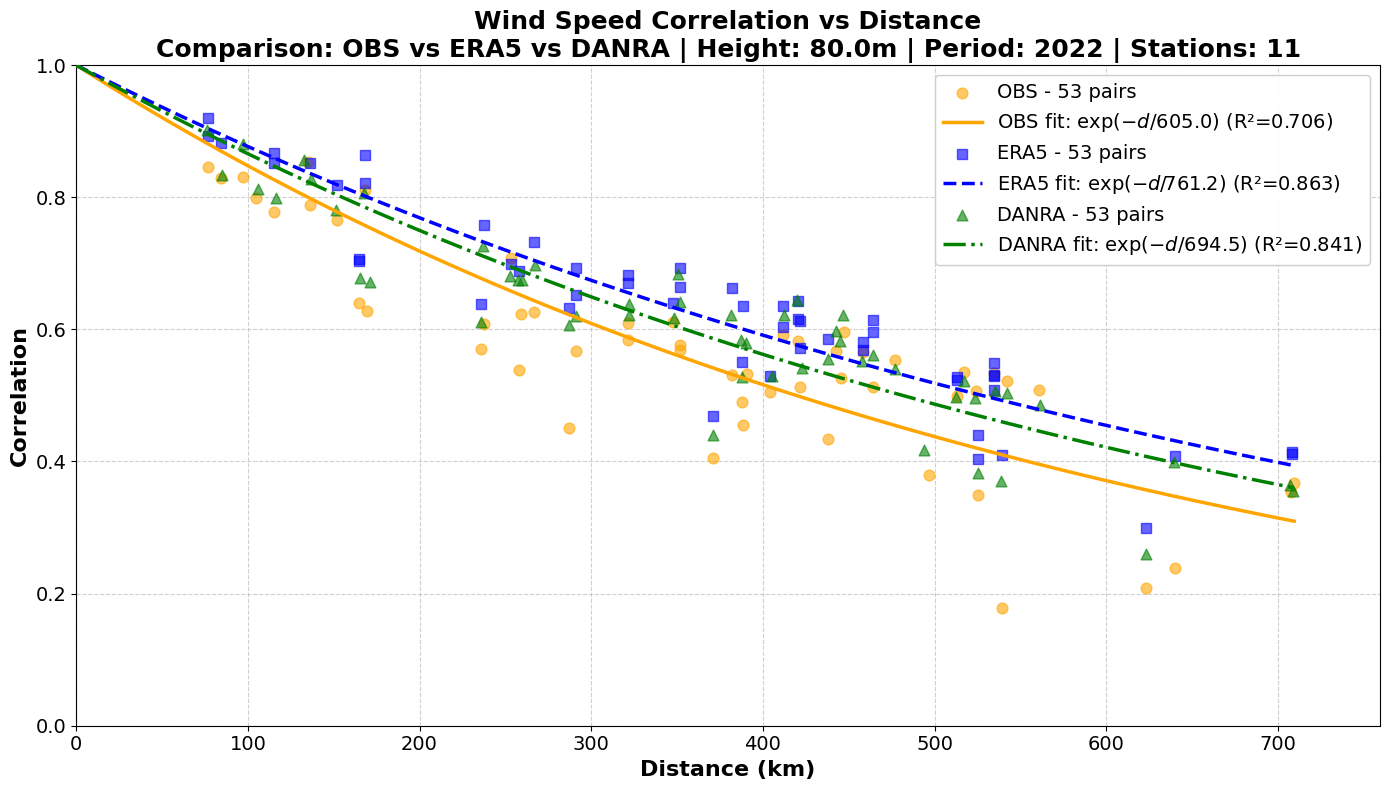


CORRELATION ANALYSIS SUMMARY
Period: 2022
Height: 80.0m

Stations used (common across OBS, ERA5, DANRA): 11
Station names: ['Balticsea_lot3', 'Balticsea_lot4', 'Cabauw', 'FINO1', 'FINO2', 'FINO3', 'Hamburg', 'Hovsore', 'Northsea_lot1', 'Northsea_lot2', 'Oesterild']

Common pairs across all three datasets: 53

OBS  pairs: 53
ERA5 pairs: 53
DANRA pairs: 53

OBS  correlation length: 605.05 km (R²=0.706)
ERA5 correlation length: 761.16 km (R²=0.863)
DANRA correlation length: 694.50 km (R²=0.841)


In [21]:
# SECTION 4: CORRELATION ANALYSIS & FITTING
# ================================

import matplotlib.pyplot as plt
import traceback

# Close all existing figures before starting
plt.close('all')
print("Closed all existing figures")

# ================================
# COMPUTE CORRELATIONS AND FILTER TO COMMON STATIONS
# ================================
print("\n" + "-" * 50)
print("COMPUTING CORRELATIONS (Common stations only)")
print("-" * 50)

# First, compute correlations for each dataset
obs_distances, obs_correlations, obs_pairs = compute_correlations_and_distances(
    filtered_obs, "OBS", TARGET_YEARS)
era5_distances, era5_correlations, era5_pairs = compute_correlations_and_distances(
    filtered_era5, "ERA5", TARGET_YEARS)
danra_distances, danra_correlations, danra_pairs = compute_correlations_and_distances(
    filtered_danra, "DANRA", TARGET_YEARS)

# Extract station names from pairs
def get_stations_from_pairs(pairs):
    """Extract unique station names from pair names."""
    stations = set()
    for pair in pairs:
        station1, station2 = pair.split('-')
        stations.add(station1)
        stations.add(station2)
    return stations

obs_stations_used = get_stations_from_pairs(obs_pairs)
era5_stations_used = get_stations_from_pairs(era5_pairs)
danra_stations_used = get_stations_from_pairs(danra_pairs)

print("\n" + "-" * 20)
print("Stations used in correlations:")
print(f"  OBS:   {sorted(obs_stations_used)} ({len(obs_stations_used)} stations)")
print(f"  ERA5:  {sorted(era5_stations_used)} ({len(era5_stations_used)} stations)")
print(f"  DANRA: {sorted(danra_stations_used)} ({len(danra_stations_used)} stations)")

# Find stations that are common across ALL THREE datasets' correlation pairs
common_correlation_stations = obs_stations_used & era5_stations_used & danra_stations_used
print(f"\nStations common to all three correlation analyses: {sorted(common_correlation_stations)} ({len(common_correlation_stations)} stations)")

# Filter to only stations that appear in all three correlation analyses
filtered_obs_final = {station: filtered_obs[station] for station in common_correlation_stations}
filtered_era5_final = {station: filtered_era5[station] for station in common_correlation_stations}
filtered_danra_final = {station: filtered_danra[station] for station in common_correlation_stations}

print(f"\nFinal station counts for plotting:")
print(f"  OBS:   {len(filtered_obs_final)}")
print(f"  ERA5:  {len(filtered_era5_final)}")
print(f"  DANRA: {len(filtered_danra_final)}")
print(f"  Stations: {sorted(common_correlation_stations)}")

# Store the final common stations for summary
final_stations = sorted(common_correlation_stations)

# Recompute correlations with only the common stations
if len(common_correlation_stations) >= 2:
    print("\n" + "-" * 50)
    print("RECOMPUTING CORRELATIONS (Final common stations only)")
    print("-" * 50)
    print(f"Using {len(common_correlation_stations)} common stations: {final_stations}")
    
    obs_distances, obs_correlations, obs_pairs = compute_correlations_and_distances(
        filtered_obs_final, "OBS (final)", TARGET_YEARS)
    era5_distances, era5_correlations, era5_pairs = compute_correlations_and_distances(
        filtered_era5_final, "ERA5 (final)", TARGET_YEARS)
    danra_distances, danra_correlations, danra_pairs = compute_correlations_and_distances(
        filtered_danra_final, "DANRA (final)", TARGET_YEARS)
    
    print(f"\nFinal pairs count:")
    print(f"  OBS:   {len(obs_pairs)} pairs from {len(filtered_obs_final)} stations")
    print(f"  ERA5:  {len(era5_pairs)} pairs from {len(filtered_era5_final)} stations")
    print(f"  DANRA: {len(danra_pairs)} pairs from {len(filtered_danra_final)} stations")
    
    # ================================
    # FILTER TO ONLY COMMON PAIRS ACROSS ALL THREE DATASETS
    # ================================
    print("\n" + "-" * 50)
    print("FILTERING TO COMMON PAIRS ACROSS ALL THREE DATASETS")
    print("-" * 50)
    
    # Create dictionaries mapping pair names to distances and correlations
    obs_pair_dict = {pair: (dist, corr) for pair, dist, corr in zip(obs_pairs, obs_distances, obs_correlations)}
    era5_pair_dict = {pair: (dist, corr) for pair, dist, corr in zip(era5_pairs, era5_distances, era5_correlations)}
    danra_pair_dict = {pair: (dist, corr) for pair, dist, corr in zip(danra_pairs, danra_distances, danra_correlations)}
    
    # Find common pairs (pairs that exist in all three datasets)
    common_pairs = set(obs_pair_dict.keys()) & set(era5_pair_dict.keys()) & set(danra_pair_dict.keys())
    print(f"Common pairs across all three datasets: {len(common_pairs)}")
    
    # Create filtered lists for common pairs only
    filtered_obs_distances = []
    filtered_obs_correlations = []
    filtered_obs_pairs = []
    
    filtered_era5_distances = []
    filtered_era5_correlations = []
    filtered_era5_pairs = []
    
    filtered_danra_distances = []
    filtered_danra_correlations = []
    filtered_danra_pairs = []
    
    for pair in sorted(common_pairs):
        # OBS
        obs_dist, obs_corr = obs_pair_dict[pair]
        filtered_obs_distances.append(obs_dist)
        filtered_obs_correlations.append(obs_corr)
        filtered_obs_pairs.append(pair)
        
        # ERA5
        era5_dist, era5_corr = era5_pair_dict[pair]
        filtered_era5_distances.append(era5_dist)
        filtered_era5_correlations.append(era5_corr)
        filtered_era5_pairs.append(pair)
        
        # DANRA
        danra_dist, danra_corr = danra_pair_dict[pair]
        filtered_danra_distances.append(danra_dist)
        filtered_danra_correlations.append(danra_corr)
        filtered_danra_pairs.append(pair)
    
    print(f"Filtered pairs count:")
    print(f"  OBS:   {len(filtered_obs_pairs)} pairs")
    print(f"  ERA5:  {len(filtered_era5_pairs)} pairs")
    print(f"  DANRA: {len(filtered_danra_pairs)} pairs")
    
    # Show first few common pairs
    if len(common_pairs) > 0:
        print(f"\nSample common pairs: {sorted(common_pairs)[:10]}")
    
    # Fit exponential models using only common pairs
    print("\n" + "-" * 50)
    print("FITTING EXPONENTIAL MODELS (Common pairs only)")
    print("-" * 50)
    
    obs_L, obs_R2 = fit_exponential_model(filtered_obs_distances, filtered_obs_correlations, "OBS")
    era5_L, era5_R2 = fit_exponential_model(filtered_era5_distances, filtered_era5_correlations, "ERA5")
    danra_L, danra_R2 = fit_exponential_model(filtered_danra_distances, filtered_danra_correlations, "DANRA")
    
    # Create plot with common pairs only
    print("\n" + "-" * 50)
    print("GENERATING PLOT")
    print("-" * 50)
    
    create_correlation_plot(
        filtered_obs_distances, filtered_obs_correlations, obs_L, obs_R2,
        filtered_era5_distances, filtered_era5_correlations, era5_L, era5_R2,
        filtered_danra_distances, filtered_danra_correlations, danra_L, danra_R2,
        TARGET_HEIGHT, TARGET_YEARS,
        final_stations  # Pass the common stations for the plot
    )
    plot_created = True
else:
    print("\nWARNING: Less than 2 stations common across all three datasets.")
    print(f"  Common stations: {sorted(common_correlation_stations)}")
    plot_created = False
    
# ================================
# SECTION 5: FINAL SUMMARY
# ================================

years_str = format_years_string(TARGET_YEARS)
print("\n" + "=" * 70)
print("CORRELATION ANALYSIS SUMMARY")
print("=" * 70)
print(f"Period: {years_str}")
print(f"Height: {TARGET_HEIGHT}m")
print(f"\nStations used (common across OBS, ERA5, DANRA): {len(filtered_obs_final)}")
if len(filtered_obs_final) > 0:
    print(f"Station names: {sorted(filtered_obs_final.keys())}")
print(f"\nCommon pairs across all three datasets: {len(common_pairs)}")
print(f"\nOBS  pairs: {len(filtered_obs_pairs)}")
print(f"ERA5 pairs: {len(filtered_era5_pairs)}")
print(f"DANRA pairs: {len(filtered_danra_pairs)}")
print(f"\nOBS  correlation length: {obs_L:.2f} km (R²={obs_R2:.3f})" if obs_L else "OBS  correlation length: Fit failed")
print(f"ERA5 correlation length: {era5_L:.2f} km (R²={era5_R2:.3f})" if era5_L else "ERA5 correlation length: Fit failed")
print(f"DANRA correlation length: {danra_L:.2f} km (R²={danra_R2:.3f})" if danra_L else "DANRA correlation length: Fit failed")
print("=" * 70)

In [22]:
# ================================
# SECTION 5: FINAL SUMMARY
# ================================

years_str = format_years_string(TARGET_YEARS)
print("\n" + "=" * 70)
print("CORRELATION ANALYSIS SUMMARY")
print("=" * 70)
print(f"Period: {years_str}")
print(f"Height: {TARGET_HEIGHT}m")
print(f"\nOBS  stations: {len(obs_stations)}")
print(f"ERA5 stations: {len(era5_stations)}")
print(f"DANRA stations: {len(danra_stations)}")
print(f"\nOBS  pairs: {len(obs_distances)}")
print(f"ERA5 pairs: {len(era5_distances)}")
print(f"DANRA pairs: {len(danra_distances)}")
print(f"\nOBS  correlation length: {obs_L:.2f} km (R²={obs_R2:.3f})" if obs_L else "OBS  correlation length: Fit failed")
print(f"ERA5 correlation length: {era5_L:.2f} km (R²={era5_R2:.3f})" if era5_L else "ERA5 correlation length: Fit failed")
print(f"DANRA correlation length: {danra_L:.2f} km (R²={danra_R2:.3f})" if danra_L else "DANRA correlation length: Fit failed")
print("=" * 70)



CORRELATION ANALYSIS SUMMARY
Period: 2022
Height: 80.0m

OBS  stations: 11
ERA5 stations: 14
DANRA stations: 11

OBS  pairs: 55
ERA5 pairs: 53
DANRA pairs: 55

OBS  correlation length: 605.05 km (R²=0.706)
ERA5 correlation length: 761.16 km (R²=0.863)
DANRA correlation length: 694.50 km (R²=0.841)
